<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/neural_networks/lab 10 - CNNs for image classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Convolutional Neural Networks (CNN) for image classification

In the previous lab an MLP reached about 88% on Fashion-MNIST, and its accuracy collapsed when the images were shifted by 2 or 3 pixels. The MLP flattens the image and has no idea which pixels are neighbours. A **convolutional neural network** builds two facts about images into its architecture:

- **Locality**: to recognise an edge, a corner or a texture you only need to look at a small neighbourhood of pixels.
- **Weight sharing**: a pattern means the same thing wherever it appears, so the same detector can be slid over the whole image.

The result is a model with **10 times fewer parameters** than the MLP that is also **more accurate**.

**Contents**

1. Setup and data (same split as the MLP lab)
2. Why MLPs are a poor fit for images
3. The convolution operation, from scratch
4. Padding, stride and the output size
5. Channels and the parameter count
6. Translation equivariance (proof and check)
7. Pooling
8. The receptive field
9. The CNN model
10. Training and evaluation
11. Inside the CNN: learned filters and feature maps
12. Shifted images: CNN vs MLP
13. Fighting overfitting: data augmentation and dropout
14. A stronger CNN: more filters, batch normalisation
15. Final comparison on the test set
16. Summary and exercises

Theory: [`notes/neural_networks/03_cnn_transfer_multitask`](https://imagra93.github.io/ML-course-labs/notes/neural_networks/03_cnn_transfer_multitask.html) (convolution, equivariance, receptive field) and [`notes/neural_networks/02_training_optimization_regularization`](https://imagra93.github.io/ML-course-labs/notes/neural_networks/02_training_optimization_regularization.html) (dropout, augmentation, batch normalisation).

**Notation**

| Symbol | Meaning |
|---|---|
| $B$ | batch size |
| $C_{\text{in}}, C_{\text{out}}$ | number of input and output channels |
| $H, W$ | height and width of an image or feature map |
| $F$ | filter (kernel) size, square $F \times F$ |
| $P$, $S$ | padding (pixels added on each side) and stride (step of the filter) |
| $K = 10$ | number of classes |

PyTorch stores a batch of images as a tensor of shape $(B, C, H, W)$: batch, channels, height, width. A grayscale image has $C = 1$, a colour image $C = 3$.

## 1. Setup and data

Same data, same pre-processing and the same train/validation/test split as the MLP lab, so the numbers can be compared directly. The one difference: a CNN keeps the image as a 2-D grid with a channel dimension, shape $(1, 28, 28)$, instead of flattening it.

This lab trains several CNNs. On a GPU it takes a few minutes; on a CPU expect 15 to 30 minutes (in Colab: *Runtime → Change runtime type → GPU*).

In [1]:
import copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision import datasets
from torchvision.transforms import v2
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

trainset = datasets.FashionMNIST("~/.pytorch/F_MNIST_data/", download=True, train=True)
testset = datasets.FashionMNIST("~/.pytorch/F_MNIST_data/", download=True, train=False)
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

train_images, train_labels = trainset.data.numpy(), trainset.targets.numpy()
test_images, test_labels = testset.data.numpy(), testset.targets.numpy()

perm = np.random.default_rng(0).permutation(len(train_images))      # same split as the MLP lab
val_idx, tr_idx = perm[:5000], perm[5000:]
mu, sigma = (train_images[tr_idx] / 255.0).mean(), (train_images[tr_idx] / 255.0).std()

def to_tensor(images):
    """uint8 (N, 28, 28) -> standardised float32 (N, 1, 28, 28): one channel."""
    return torch.tensor((images / 255.0 - mu) / sigma, dtype=torch.float32).unsqueeze(1)

X_tr, X_val, X_te = to_tensor(train_images[tr_idx]), to_tensor(train_images[val_idx]), to_tensor(test_images)
y_tr, y_val, y_te = (torch.tensor(a, dtype=torch.long) for a in (train_labels[tr_idx], train_labels[val_idx], test_labels))
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=1000)
test_loader = DataLoader(TensorDataset(X_te, y_te), batch_size=1000)
print("train", tuple(X_tr.shape), " val", tuple(X_val.shape), " test", tuple(X_te.shape))
print(f"standardised with training mean {mu:.4f} and std {sigma:.4f}")

device: cuda


train (55000, 1, 28, 28)  val (5000, 1, 28, 28)  test (10000, 1, 28, 28)
standardised with training mean 0.2862 and std 0.3531


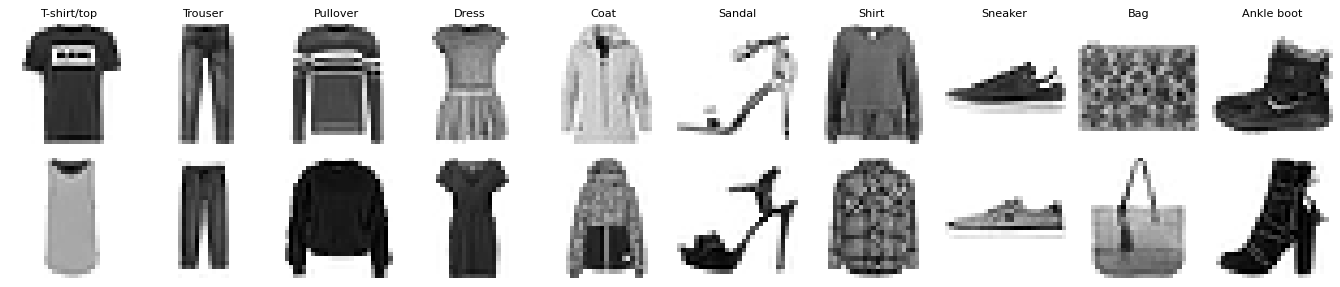

In [2]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3.4))
for k in range(10):
    for r, i in enumerate(np.where(train_labels == k)[0][:2]):
        axes[r, k].imshow(train_images[i], cmap="binary"); axes[r, k].axis("off")
    axes[0, k].set_title(class_names[k], fontsize=9)
plt.tight_layout(); plt.show()

## 2. Why MLPs are a poor fit for images

Three problems, all visible in the previous lab:

1. **Too many parameters.** The first layer connects every pixel to every hidden unit. For our tiny $28 \times 28$ images and 128 units that is $100{,}480$ weights. For a normal $224 \times 224$ colour photo ($150{,}528$ inputs) and 1000 hidden units it would be **150 million** weights in one layer, most of them learning nothing useful.
2. **No locality.** Flattening throws away which pixels are neighbours. The MLP would learn exactly as well on images whose pixels were shuffled by a fixed permutation, so it cannot be using the 2-D structure.
3. **No weight sharing.** Each weight is tied to one pixel position. A detector for "sleeve edge" learned at one position does not work one pixel to the left. That is why shifting the test images destroyed the MLP's accuracy.

A convolutional layer fixes all three with one idea: a **small filter**, the same at every position, slid over the image.

## 3. The convolution operation, from scratch

A filter (or **kernel**) is a small grid of weights, for example $3 \times 3$. To compute the output at position $(i, j)$, place the filter on the image with its top-left corner at $(i, j)$, multiply element by element, and add everything up, plus a bias:

$$
O[i, j] = \sum_{u=0}^{F-1}\sum_{v=0}^{F-1} I[i + u,\; j + v]\; K[u, v] \;+\; b .
$$

Sliding the filter over every position gives a new image, the **feature map**. Each output value is a neuron that looks only at an $F \times F$ patch (**locality**), and all these neurons use the same $F^2 + 1$ parameters (**weight sharing**).

*Terminology.* Mathematicians would flip the kernel first and call this a cross-correlation. Deep learning libraries do not flip, and call it convolution anyway. Since the kernel is learned, the difference does not matter.

Let us implement it with two loops and compare with PyTorch's `F.conv2d`.

In [3]:
def conv2d_naive(image, kernel, bias=0.0):
    """Single-channel 'valid' convolution (no padding, stride 1), written with loops."""
    H, W = image.shape
    Fk = kernel.shape[0]
    out = np.zeros((H - Fk + 1, W - Fk + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            patch = image[i:i + Fk, j:j + Fk]            # the F x F window at (i, j)
            out[i, j] = np.sum(patch * kernel) + bias    # multiply element-wise and add up
    return out

image = np.array([[1, 2, 0, 1, 3],
                  [0, 1, 3, 1, 0],
                  [2, 1, 0, 2, 1],
                  [1, 0, 1, 3, 2],
                  [0, 2, 1, 0, 1]], dtype=float)
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]], dtype=float)                # responds to left-bright / right-dark edges

ours = conv2d_naive(image, kernel)
torch_out = F.conv2d(torch.tensor(image)[None, None], torch.tensor(kernel)[None, None])[0, 0].numpy()
print("our convolution:\n", ours)
print("F.conv2d:\n", torch_out)
print("top-left value by hand: (1+0+2) - (0+3+0) =", (1 + 0 + 2) - (0 + 3 + 0))

our convolution:
 [[ 0.  0. -1.]
 [-1. -4.  1.]
 [ 1. -2. -2.]]
F.conv2d:
 [[ 0.  0. -1.]
 [-1. -4.  1.]
 [ 1. -2. -2.]]
top-left value by hand: (1+0+2) - (0+3+0) = 0


**What filters detect.** The filter above computes "left column minus right column": it is large where the image goes from bright to dark from left to right, so it is a **vertical edge detector**. Below we apply four classic hand-designed filters to a real image. A CNN **learns** its filters from data, but the first layer typically ends up learning filters like these.

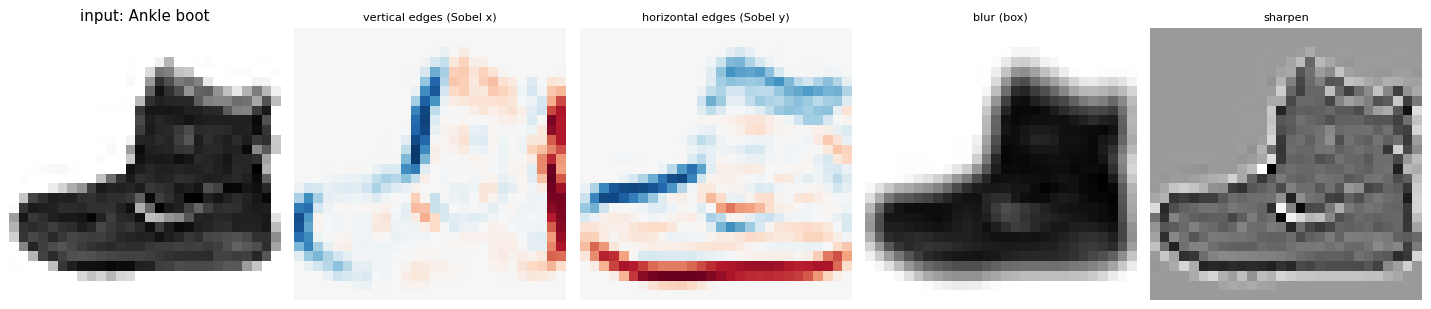

In [4]:
filters = {
    "vertical edges (Sobel x)":   [[1, 0, -1], [2, 0, -2], [1, 0, -1]],
    "horizontal edges (Sobel y)": [[1, 2, 1], [0, 0, 0], [-1, -2, -1]],
    "blur (box)":                 [[1 / 9] * 3] * 3,
    "sharpen":                    [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
}
img = torch.tensor(train_images[0] / 255.0, dtype=torch.float32)[None, None]     # (1, 1, 28, 28)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
axes[0].imshow(img[0, 0], cmap="binary"); axes[0].set_title(f"input: {class_names[train_labels[0]]}")
for ax, (name, k) in zip(axes[1:], filters.items()):
    out = F.conv2d(img, torch.tensor(k, dtype=torch.float32)[None, None], padding=1)[0, 0]
    ax.imshow(out, cmap="RdBu_r" if "edges" in name else "binary",
              **({"vmin": -out.abs().max(), "vmax": out.abs().max()} if "edges" in name else {}))
    ax.set_title(name, fontsize=9)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

Red and blue in the edge maps are edges of opposite direction. Flat regions, the background and the inside of the boot, give 0: an edge filter ignores everything except changes.

## 4. Padding, stride and the output size

**Padding** $P$ adds $P$ rows and columns of zeros around the input, so that the filter can also be centred on border pixels. **Stride** $S$ moves the filter $S$ pixels at a time instead of 1, which downsamples the output.

**Output size.** Along one dimension, the padded input has $H + 2P$ positions and the filter covers $F$ of them. The filter's first position starts at 0 and the last possible start is $H + 2P - F$. With steps of $S$, the number of positions is

$$
\boxed{H_{\text{out}} = \left\lfloor \frac{H + 2P - F}{S} \right\rfloor + 1}
$$

and the same formula holds for the width. Two cases to remember:
- $F = 3$, $P = 1$, $S = 1$ gives $H_{\text{out}} = H$ (**"same" padding**, used in our CNN). In general $P = (F - 1)/2$ for odd $F$.
- $F = 2$, $P = 0$, $S = 2$ gives $H_{\text{out}} = \lfloor H/2 \rfloor$, which halves the size (used by pooling).

In [5]:
def out_size(H, F_, P, S):
    return (H + 2 * P - F_) // S + 1

x = torch.zeros(1, 1, 28, 28)
print(f"{'F':>3}{'P':>3}{'S':>3}   formula   PyTorch")
for F_, P_, S_ in [(3, 0, 1), (3, 1, 1), (5, 2, 1), (3, 1, 2), (5, 0, 2), (7, 3, 1)]:
    real = nn.Conv2d(1, 1, F_, stride=S_, padding=P_)(x).shape[-1]
    print(f"{F_:>3}{P_:>3}{S_:>3}   {out_size(28, F_, P_, S_):>7}   {real:>7}")

  F  P  S   formula   PyTorch
  3  0  1        26        26
  3  1  1        28        28
  5  2  1        28        28
  3  1  2        14        14
  5  0  2        12        12
  7  3  1        28        28


## 5. Channels and the parameter count

Real layers work with several **channels**. The input can have $C_{\text{in}}$ channels (3 for a colour image, or the feature maps of the previous layer), and a layer produces $C_{\text{out}}$ feature maps. Each output channel has its own filter, and that filter spans **all** input channels: it has shape $C_{\text{in}} \times F \times F$. Output channel $c$ is

$$
O_c[i, j] = \sum_{c'=1}^{C_{\text{in}}}\sum_{u,v} I_{c'}[i + u, j + v]\; K_{c, c'}[u, v] + b_c .
$$

So `nn.Conv2d(C_in, C_out, F)` has a weight tensor of shape $(C_{\text{out}}, C_{\text{in}}, F, F)$ and

$$
\boxed{\#\text{params} = (F^2\, C_{\text{in}} + 1)\, C_{\text{out}}}
$$

**This does not depend on the image size.** Compare the first layer of our CNN, 8 filters of $3 \times 3$ on a $28 \times 28$ grayscale image, with a fully connected layer that produces an output of the same size, $8 \times 28 \times 28$:

In [6]:
conv = nn.Conv2d(1, 8, kernel_size=3, padding=1)
print("conv weight shape:", tuple(conv.weight.shape), " bias:", tuple(conv.bias.shape))
n_conv = sum(p.numel() for p in conv.parameters())
n_dense = (28 * 28) * (8 * 28 * 28) + 8 * 28 * 28
print(f"Conv2d(1, 8, 3):                     {n_conv:>12,} parameters  = (3*3*1 + 1) * 8")
print(f"dense layer with the same output:    {n_dense:>12,} parameters")
print(f"ratio: {n_dense / n_conv:,.0f} times more")

conv weight shape: (8, 1, 3, 3)  bias: (8,)
Conv2d(1, 8, 3):                               80 parameters  = (3*3*1 + 1) * 8
dense layer with the same output:       4,923,520 parameters
ratio: 61,544 times more


Both layers map a $28 \times 28$ image to 8 maps of $28 \times 28$. The convolution does it with 80 numbers because of locality (each output looks at 9 pixels, not 784) and weight sharing (all $28 \times 28$ positions reuse the same 9 weights). Fewer parameters means less data needed and less overfitting.

## 6. Translation equivariance

**Claim.** Shifting the input shifts the feature map by the same amount. If $I'[i, j] = I[i - a, j - b]$, then $O'[i, j] = O[i - a, j - b]$.

*Proof.* $O'[i, j] = \sum_{u,v} I'[i + u, j + v]\,K[u, v] + b = \sum_{u,v} I[i - a + u,\; j - b + v]\,K[u, v] + b = O[i - a, j - b]$, because the same kernel is used at every position. $\blacksquare$

This holds exactly away from the borders; at the borders, padding adds zeros that were not shifted. It is the formal version of "the same detector works everywhere". An edge that moves 3 pixels produces the same response, 3 pixels further. An MLP layer has no such property.

max |conv(shifted image) - shifted conv(image)| away from borders: 0.0e+00


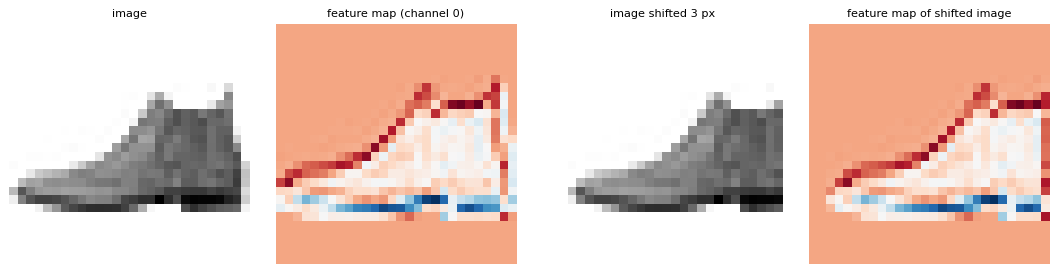

In [7]:
torch.manual_seed(0)
conv = nn.Conv2d(1, 8, 3, padding=1)
img = torch.tensor(test_images[:1] / 255.0, dtype=torch.float32)[:, None]      # (1, 1, 28, 28), background 0
shift = 3
img_shifted = torch.zeros_like(img); img_shifted[..., shift:] = img[..., :-shift]
with torch.no_grad():
    out, out_shifted = conv(img), conv(img_shifted)
# compare away from the borders: columns 4..26 of the shifted map vs columns 1..23 of the original
diff = (out_shifted[..., 1 + shift:27] - out[..., 1:27 - shift]).abs().max().item()
print(f"max |conv(shifted image) - shifted conv(image)| away from borders: {diff:.1e}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, t, title in zip(axes, [img[0, 0], out[0, 0], img_shifted[0, 0], out_shifted[0, 0]],
                        ["image", "feature map (channel 0)", f"image shifted {shift} px", "feature map of shifted image"]):
    ax.imshow(t, cmap="binary" if "image" == title.split()[0] else "RdBu_r"); ax.set_title(title, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Pooling

A **pooling** layer shrinks a feature map by summarising small windows. **Max pooling** with a $2 \times 2$ window and stride 2 keeps the largest of every 4 values:

$$
O[i, j] = \max_{0 \le u, v < 2} A[2i + u,\; 2j + v] .
$$

It halves the height and width ($28 \to 14 \to 7$) and has **no parameters**. Why use it:
- **Less computation** in the following layers: 4 times fewer positions after each pooling.
- **A larger view** for the next layer: a $3 \times 3$ filter applied after pooling covers a $6 \times 6$ region of the layer before (section 8).
- **Some invariance to small shifts.** "Is there an edge somewhere in this $2 \times 2$ window?" gives the same answer if the edge moves by one pixel inside the window. This is only partial: a shift that crosses a window boundary changes the output.

Convolution is **equivariant** (shift in, shift out). Pooling makes the representation more **invariant** (shift in, same out), which is what classification needs: a shirt is a shirt wherever it is.

**Average pooling** takes the mean instead of the maximum. Modern networks often end with *global* average pooling, which averages each feature map to a single number.

In [8]:
A = torch.tensor([[1., 3., 0., 2.],
                  [4., 2., 1., 0.],
                  [0., 1., 5., 6.],
                  [2., 0., 7., 1.]])[None, None]
print("input 4x4:\n", A[0, 0])
print("max pool 2x2, stride 2:\n", F.max_pool2d(A, 2)[0, 0])
print("average pool 2x2, stride 2:\n", F.avg_pool2d(A, 2)[0, 0])

input 4x4:
 tensor([[1., 3., 0., 2.],
        [4., 2., 1., 0.],
        [0., 1., 5., 6.],
        [2., 0., 7., 1.]])
max pool 2x2, stride 2:
 tensor([[4., 2.],
        [2., 7.]])
average pool 2x2, stride 2:
 tensor([[2.5000, 0.7500],
        [0.7500, 4.7500]])


## 8. The receptive field

The **receptive field** of a unit is the region of the **input image** that can affect its value. A unit of the first $3 \times 3$ convolution sees a $3 \times 3$ patch. Deeper units see more, because they combine units that already see patches.

**Rule.** Let $R_l$ be the receptive field after layer $l$, and $J_{l-1}$ the product of the strides of all previous layers (the distance in input pixels between two neighbouring units of layer $l-1$). A layer with kernel $F_l$ and stride $S_l$ gives

$$
R_l = R_{l-1} + (F_l - 1)\,J_{l-1}, \qquad J_l = J_{l-1}\,S_l, \qquad R_0 = 1,\; J_0 = 1 .
$$

Each extra kernel position adds a step of $J_{l-1}$ input pixels. For our network:

| Layer | $F$ | $S$ | $R$ (input pixels) | $J$ |
|---|---|---|---|---|
| input | | | 1 | 1 |
| conv1 $3 \times 3$ | 3 | 1 | $1 + 2 \cdot 1 = 3$ | 1 |
| max pool $2 \times 2$ | 2 | 2 | $3 + 1 \cdot 1 = 4$ | 2 |
| conv2 $3 \times 3$ | 3 | 1 | $4 + 2 \cdot 2 = 8$ | 2 |
| max pool $2 \times 2$ | 2 | 2 | $8 + 1 \cdot 2 = 10$ | 4 |

So each value of the final $7 \times 7$ feature maps summarises a $10 \times 10$ patch of the $28 \times 28$ image. Stacking layers, and pooling in between, is how CNNs go from local edges to larger parts.

**Checking it with autograd.** The receptive field is exactly the set of input pixels with a non-zero gradient $\partial(\text{unit})/\partial(\text{input})$. We build the same stack of layers with random weights, using average pooling so that every pixel in the window receives gradient, and look at which pixels get a gradient.

output shape: (1, 4, 7, 7)
input pixels that influence unit (3, 3): rows 9..18, cols 9..18  ->  10 x 10


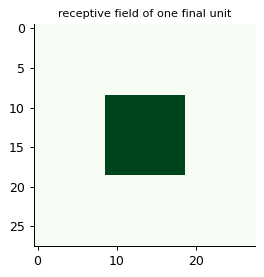

In [9]:
torch.manual_seed(0)
stack = nn.Sequential(nn.Conv2d(1, 4, 3, padding=1), nn.AvgPool2d(2), nn.Conv2d(4, 4, 3, padding=1), nn.AvgPool2d(2))
x = torch.randn(1, 1, 28, 28, requires_grad=True)
out = stack(x)                                   # (1, 4, 7, 7)
out[0, 0, 3, 3].backward()                       # one unit in the middle of the final map
support = (x.grad[0, 0].abs() > 0)
rows, cols = support.any(1).nonzero().ravel(), support.any(0).nonzero().ravel()
print("output shape:", tuple(out.shape))
print(f"input pixels that influence unit (3, 3): rows {rows.min().item()}..{rows.max().item()}, "
      f"cols {cols.min().item()}..{cols.max().item()}  ->  {len(rows)} x {len(cols)}")
plt.figure(figsize=(3.2, 3.2)); plt.imshow(x.grad[0, 0].abs() > 0, cmap="Greens"); plt.grid(False)
plt.title("receptive field of one final unit", fontsize=9); plt.show()

## 9. The CNN model

The architecture of the original lab, with one change: `forward` returns **logits** and we use `nn.CrossEntropyLoss`, as in the MLP lab. (Returning `F.log_softmax` and using `nn.NLLLoss` is equivalent.)

| Layer | Output shape | Parameters |
|---|---|---|
| input | $(B, 1, 28, 28)$ | |
| conv1: 8 filters $3 \times 3$, $P = 1$, ReLU | $(B, 8, 28, 28)$ | $(9 \cdot 1 + 1) \cdot 8 = 80$ |
| max pool $2 \times 2$ | $(B, 8, 14, 14)$ | 0 |
| conv2: 16 filters $3 \times 3$, $P = 1$, ReLU | $(B, 16, 14, 14)$ | $(9 \cdot 8 + 1) \cdot 16 = 1{,}168$ |
| max pool $2 \times 2$ | $(B, 16, 7, 7)$ | 0 |
| flatten | $(B, 784)$ | 0 |
| linear | $(B, 10)$ | $(784 + 1) \cdot 10 = 7{,}850$ |
| **total** | | **9,098** |

The convolutional part is a **feature extractor**: it turns the image into 16 maps of $7 \times 7$ that say which patterns were found roughly where. The final linear layer is a **softmax regression on those learned features**, the same classifier as the baseline of the MLP lab, but on much better inputs.

The `summary` helper prints the shapes, as `torchsummary` does, using forward hooks.

In [10]:
class CNN(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)    # (B, 1, 28, 28) -> (B, 8, 28, 28)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)   # (B, 8, 14, 14) -> (B, 16, 14, 14)
        self.pool = nn.MaxPool2d(2, 2)                            # halves height and width
        self.dropout = nn.Dropout(dropout)                        # identity when dropout = 0
        self.fc = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        x = x.reshape(-1, 1, 28, 28)
        x = self.pool(F.relu(self.conv1(x)))   # (B, 8, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))   # (B, 16, 7, 7)
        x = x.flatten(1)                       # (B, 784)
        x = self.dropout(x)
        return self.fc(x)                      # (B, 10) logits

def summary(model, input_shape=(1, 28, 28)):
    rows, hooks = [], []
    for name, mod in model.named_modules():
        if len(list(mod.children())) == 0:
            hooks.append(mod.register_forward_hook(
                lambda m, i, o, name=name: rows.append((name, type(m).__name__, tuple(o.shape), sum(p.numel() for p in m.parameters())))))
    model.eval()
    with torch.no_grad():
        model(torch.zeros(1, *input_shape, device=next(model.parameters()).device))
    for h in hooks: h.remove()
    print(f"{'layer':<15}{'type':<19}{'output shape':<18}{'params':>10}")
    for r in rows: print(f"{r[0]:<15}{r[1]:<19}{str(r[2]):<18}{r[3]:>10,}")
    print(f"{'total':<52}{sum(p.numel() for p in model.parameters()):>10,}")

summary(CNN())

layer          type               output shape          params
conv1          Conv2d             (1, 8, 28, 28)            80
pool           MaxPool2d          (1, 8, 14, 14)             0
conv2          Conv2d             (1, 16, 14, 14)        1,168
pool           MaxPool2d          (1, 16, 7, 7)              0
dropout        Dropout            (1, 784)                   0
fc             Linear             (1, 10)                7,850
total                                                    9,098


The shapes are recorded in the order the layers are called, which is why `pool` appears twice and `dropout` is listed before `fc`.

## 10. Training and evaluation

The `fit` function is the one from the MLP lab: Adam, mini-batches of 64, validation after every epoch, and **early stopping** (the weights of the epoch with the lowest validation loss are restored at the end). We use a learning rate of $2 \cdot 10^{-3}$ and train for 20 epochs. (The original lab used $5 \cdot 10^{-3}$, which makes the validation curve noisier.)

For comparison we also train the MLP of the previous lab, 784-128-10, with the same loop.

In [11]:
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    total, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item(); n += len(yb)
    return total / n, correct / n

def predict(model, X, batch=2000):
    model.eval()
    with torch.no_grad():
        return torch.cat([torch.softmax(model(X[i:i + batch].to(device)), 1).cpu() for i in range(0, len(X), batch)]).numpy()

def fit(model, train_loader, val_loader, epochs=20, lr=2e-3, weight_decay=0.0, verbose=True):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc")}
    best = (float("inf"), None, 0)
    for epoch in range(epochs):
        model.train()
        tot, correct, n, t0 = 0.0, 0, 0, time.time()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            tot += loss.item() * len(yb); correct += (logits.argmax(1) == yb).sum().item(); n += len(yb)
        vl, va = evaluate(model, val_loader)
        for k, v in zip(hist, (tot / n, correct / n, vl, va)): hist[k].append(v)
        if vl < best[0]:
            best = (vl, copy.deepcopy(model.state_dict()), epoch)
        if verbose and (epoch % 2 == 1 or epoch == epochs - 1):
            print(f"epoch {epoch + 1:2d}  train loss {tot / n:.4f} acc {correct / n:.4f}   "
                  f"val loss {vl:.4f} acc {va:.4f}   ({time.time() - t0:.1f}s)")
    model.load_state_dict(best[1])
    hist["best_epoch"] = best[2]
    if verbose:
        print(f"-> restored epoch {best[2] + 1}: val loss {best[0]:.4f}, val acc {hist['val_acc'][best[2]]:.4f}")
    return hist

def plot_histories(hists, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
    for (name, h), c in zip(hists.items(), ["C0", "C1", "C2", "C3"]):
        ep = np.arange(1, len(h["train_loss"]) + 1)
        for ax, key in zip(axes, ["loss", "acc"]):
            ax.plot(ep, h[f"val_{key}"], "o-", ms=3, color=c, label=f"{name}: validation")
            ax.plot(ep, h[f"train_{key}"], "--", color=c, lw=1, label=f"{name}: training")
    axes[0].set_ylabel("cross-entropy loss"); axes[1].set_ylabel("accuracy")
    for ax in axes: ax.set_xlabel("epoch"); ax.legend(fontsize=7)
    fig.suptitle(title); plt.tight_layout(); plt.show()

torch.manual_seed(0)
cnn = CNN()
hist_cnn = fit(cnn, train_loader, val_loader, epochs=20)

epoch  2  train loss 0.3284 acc 0.8837   val loss 0.3179 acc 0.8858   (0.8s)


epoch  4  train loss 0.2765 acc 0.9010   val loss 0.2957 acc 0.8898   (0.8s)


epoch  6  train loss 0.2510 acc 0.9091   val loss 0.2715 acc 0.9012   (0.9s)


epoch  8  train loss 0.2344 acc 0.9149   val loss 0.2928 acc 0.8960   (0.8s)


epoch 10  train loss 0.2233 acc 0.9188   val loss 0.2936 acc 0.8946   (0.8s)


epoch 12  train loss 0.2142 acc 0.9218   val loss 0.2633 acc 0.9052   (0.8s)


epoch 14  train loss 0.2075 acc 0.9244   val loss 0.2618 acc 0.9060   (0.8s)


epoch 16  train loss 0.2006 acc 0.9265   val loss 0.2565 acc 0.9066   (0.8s)


epoch 18  train loss 0.1968 acc 0.9284   val loss 0.2624 acc 0.9072   (0.8s)


epoch 20  train loss 0.1932 acc 0.9290   val loss 0.2729 acc 0.9046   (0.8s)
-> restored epoch 17: val loss 0.2523, val acc 0.9104


MLP 784-128-10    101,770 params   best epoch  9   train acc 0.9147   val acc 0.8906
CNN                 9,098 params   best epoch 17   train acc 0.9276   val acc 0.9104


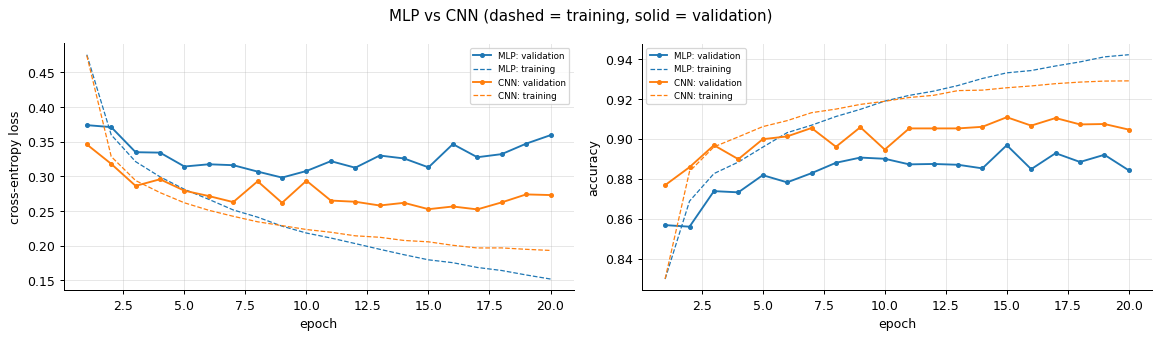

In [12]:
torch.manual_seed(0)
mlp = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
hist_mlp = fit(mlp, train_loader, val_loader, epochs=20, lr=1e-3, verbose=False)
for name, m, h in [("MLP 784-128-10", mlp, hist_mlp), ("CNN", cnn, hist_cnn)]:
    b = h["best_epoch"]
    print(f"{name:<16} {sum(p.numel() for p in m.parameters()):>8,} params   best epoch {b + 1:2d}   "
          f"train acc {h['train_acc'][b]:.4f}   val acc {h['val_acc'][b]:.4f}")
plot_histories({"MLP": hist_mlp, "CNN": hist_cnn}, "MLP vs CNN (dashed = training, solid = validation)")

**Reading the result.** With about **11 times fewer parameters**, the CNN beats the MLP on the validation set. The dashed and solid curves also show that both models overfit after a while: the training loss keeps falling while the validation loss turns up. Early stopping protects us, but a large gap between training and validation accuracy means the model could generalise better. Section 13 attacks that gap.

**Confusion matrix on the test set.** We look at it once here, to see which errors remain; the final comparison of all models is in section 15.

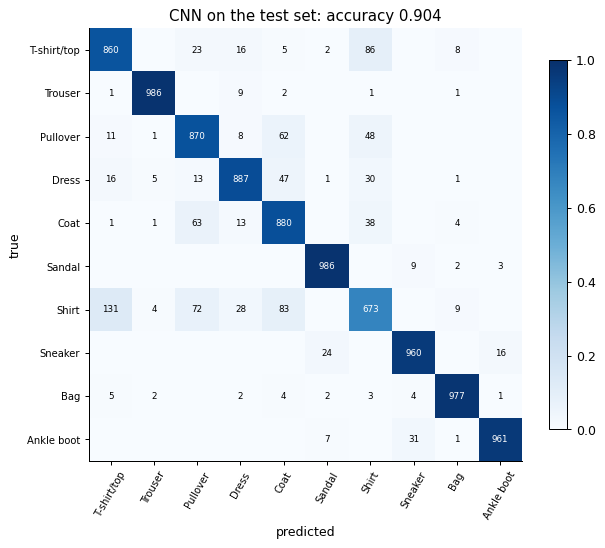

recall per class: T-shirt/top 0.86, Trouser 0.99, Pullover 0.87, Dress 0.89, Coat 0.88, Sandal 0.99, Shirt 0.67, Sneaker 0.96, Bag 0.98, Ankle boot 0.96


In [13]:
from sklearn.metrics import confusion_matrix
probs_cnn = predict(cnn, X_te)
pred_cnn = probs_cnn.argmax(1)
cm = confusion_matrix(test_labels, pred_cnn)
cm_norm = cm / cm.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(7.2, 6.2))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
for i in range(10):
    for j in range(10):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7, color="white" if cm_norm[i, j] > 0.5 else "black")
ax.set_xticks(range(10)); ax.set_xticklabels(class_names, rotation=60, fontsize=8)
ax.set_yticks(range(10)); ax.set_yticklabels(class_names, fontsize=8); ax.grid(False)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"CNN on the test set: accuracy {np.mean(pred_cnn == test_labels):.3f}")
fig.colorbar(im, shrink=0.8); plt.tight_layout(); plt.show()
recall = np.diag(cm_norm)
print("recall per class:", ", ".join(f"{c} {r:.2f}" for c, r in zip(class_names, recall)))

The pattern of errors is the same as for the MLP, with fewer of them: shirts are confused with T-shirts, pullovers and coats. These classes differ in details (collars, buttons, sleeve length) that are hard to see at $28 \times 28$ pixels.

## 11. Inside the CNN: learned filters and feature maps

The first layer has 8 filters of $3 \times 3$. Each one is a tiny image of weights. Below: the filters, and the 8 feature maps they produce on one test image, followed by the 16 feature maps of the second layer.

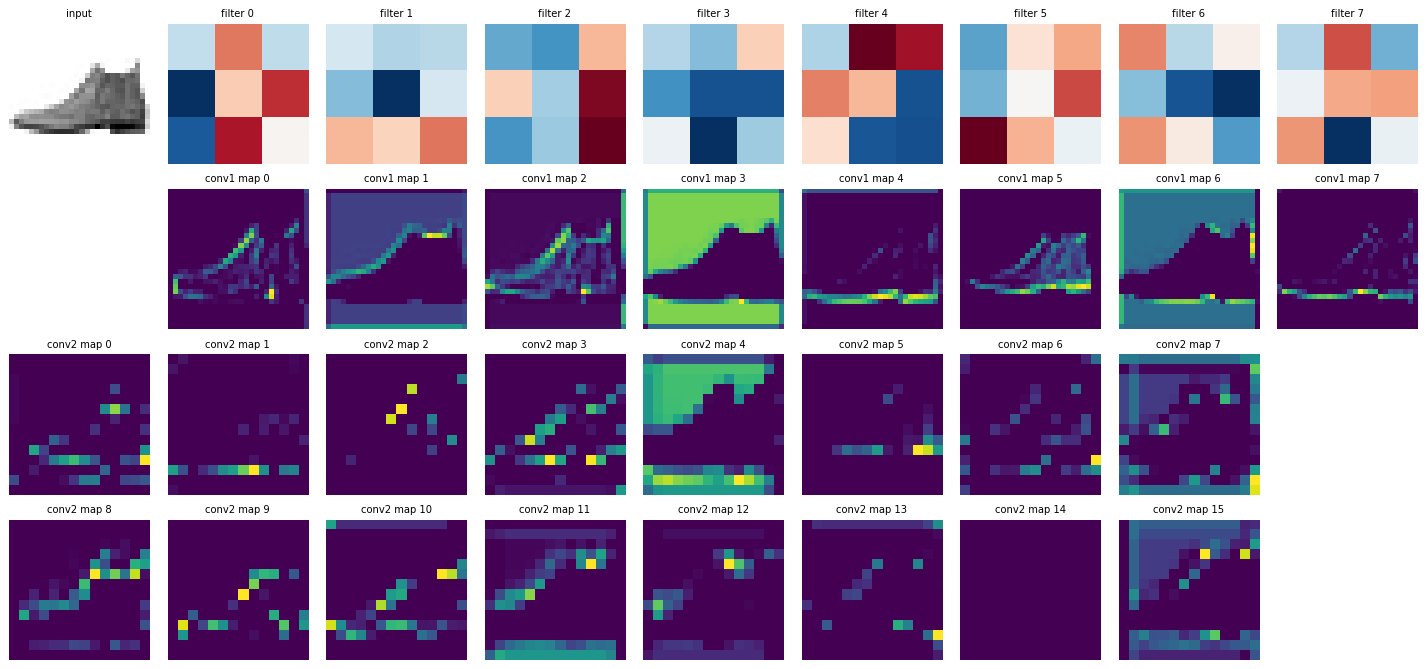

In [14]:
w1 = cnn.conv1.weight.detach().cpu()[:, 0]                 # (8, 3, 3)
x0 = X_te[:1].to(device)
cnn.eval()
with torch.no_grad():
    a1 = F.relu(cnn.conv1(x0))[0].cpu()                    # (8, 28, 28)
    a2 = F.relu(cnn.conv2(cnn.pool(F.relu(cnn.conv1(x0)))))[0].cpu()   # (16, 14, 14)

fig = plt.figure(figsize=(16, 7.5))
ax = fig.add_subplot(4, 9, 1); ax.imshow(test_images[0], cmap="binary"); ax.set_title("input", fontsize=8); ax.axis("off")
for k in range(8):
    ax = fig.add_subplot(4, 9, k + 2); l = w1[k].abs().max()
    ax.imshow(w1[k], cmap="RdBu_r", vmin=-l, vmax=l); ax.set_title(f"filter {k}", fontsize=8); ax.axis("off")
    ax = fig.add_subplot(4, 9, 9 + k + 2)
    ax.imshow(a1[k], cmap="viridis"); ax.set_title(f"conv1 map {k}", fontsize=8); ax.axis("off")
for k in range(16):
    ax = fig.add_subplot(4, 9, 19 + k if k < 8 else 20 + k)
    ax.imshow(a2[k], cmap="viridis"); ax.set_title(f"conv2 map {k}", fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

- The first-layer filters look like the hand-designed ones of section 3: positive on one side and negative on the other (edge detectors in different directions), or all of one sign (brightness and blur).
- The first-layer maps are still recognisable versions of the input: each highlights the edges or regions that one filter responds to. After ReLU, dark means "not found here".
- The second-layer maps are half the size and more abstract. Each combines all 8 first-layer maps over a $8 \times 8$ receptive field, so it responds to combinations such as "a vertical edge next to a horizontal edge". Deeper networks continue this hierarchy up to object parts.

## 12. Shifted images: CNN vs MLP

We repeat the experiment of the MLP lab: shift every test image a few pixels to the right and measure the accuracy.

In [15]:
def shift_images(X, dx):
    if dx == 0:
        return X
    out = torch.full_like(X, X.min().item())            # fill with the background value
    out[..., dx:] = X[..., :-dx]
    return out

shifts = [0, 1, 2, 3, 4, 5]
def shift_curve(model):
    return [evaluate(model, DataLoader(TensorDataset(shift_images(X_te, s), y_te), batch_size=1000))[1] for s in shifts]

shift_results = {"MLP 784-128-10": shift_curve(mlp), "CNN": shift_curve(cnn)}
for name, accs in shift_results.items():
    print(f"{name:<16}", "  ".join(f"{s}px: {a:.3f}" for s, a in zip(shifts, accs)))

MLP 784-128-10   0px: 0.883  1px: 0.804  2px: 0.532  3px: 0.334  4px: 0.257  5px: 0.266
CNN              0px: 0.904  1px: 0.868  2px: 0.755  3px: 0.552  4px: 0.315  5px: 0.227


The CNN degrades more slowly than the MLP, but it still loses a lot. Why is it not immune?
- The convolutions are equivariant, and pooling adds only a little invariance (to shifts inside a $2 \times 2$ window).
- The **final linear layer** is attached to positions of the $7 \times 7$ maps, just like an MLP's first layer is attached to pixels. A shift of 4 input pixels moves the features by one cell of the $7 \times 7$ grid, and the linear layer sees a different input.
- The network has only ever seen centred images, so it had no reason to learn anything else.

Two standard fixes: **global average pooling** before the classifier (averaging each map over all positions removes the position completely), and **data augmentation** with random shifts, which shows the network that position does not matter. We use the second one next.

## 13. Fighting overfitting: data augmentation and dropout

### Data augmentation

The idea: create new training examples by applying random transformations that **do not change the label**. Every epoch the network sees a slightly different version of each image, so it cannot memorise the exact pixels, and it learns the invariances we want.

Which transformations are safe depends on the problem:
- **Horizontal flip**: a mirrored sneaker is still a sneaker. For digits it would be wrong (a flipped 2 is not a 2).
- **Small translations** (here up to 2 pixels): the class does not depend on the exact position.
- Small rotations, zooms and brightness changes are common for photos. Vertical flips usually are not (upside-down shoes do not occur).

Augmentation is applied **only to the training set**, on the fly, each time an example is loaded. Validation and test images are left untouched. We implement it with a `Dataset` whose `__getitem__` applies a random transform to each image, the pattern seen in the PyTorch lab. `torchvision.transforms.v2` provides the transformations. We apply them to images scaled to $[0, 1]$, where the background is exactly 0, and standardise afterwards.

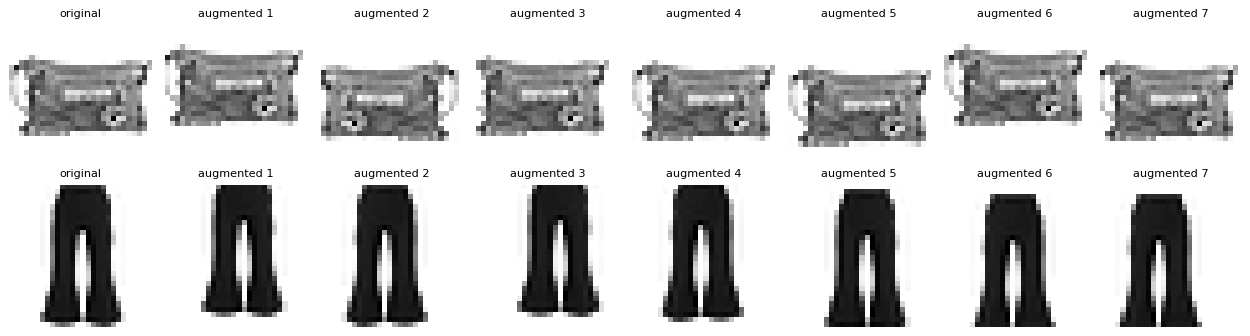

In [16]:
class AugmentedFashion(Dataset):
    """Training images with a random transform applied every time an example is requested."""
    def __init__(self, images_uint8, labels, transform):
        self.images = torch.tensor(images_uint8, dtype=torch.float32).div(255).unsqueeze(1)   # (N, 1, 28, 28) in [0, 1]
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.transform(self.images[idx])                  # random flip and shift, different every call
        return (x - mu) / sigma, self.labels[idx]             # standardise with the training statistics

flip_only = v2.RandomHorizontalFlip(p=0.5)
flip_shift = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomCrop(28, padding=2, fill=0),                     # pad 2 px of background, crop 28x28 at a random position
])
def make_loader(transform):
    ds = AugmentedFashion(train_images[tr_idx], train_labels[tr_idx], transform)
    return ds, DataLoader(ds, batch_size=64, shuffle=True, num_workers=2, persistent_workers=True)

train_flip, train_loader_flip = make_loader(flip_only)
train_aug, train_loader_aug = make_loader(flip_shift)

fig, axes = plt.subplots(2, 8, figsize=(14, 3.8))
for r, i in enumerate([0, 3]):          # examples of the flip + shift pipeline
    axes[r, 0].imshow(train_aug.images[i, 0], cmap="binary"); axes[r, 0].set_title("original", fontsize=9)
    for c in range(1, 8):
        axes[r, c].imshow(train_aug[i][0][0], cmap="binary"); axes[r, c].set_title(f"augmented {c}", fontsize=9)
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()

### Dropout

During training, `nn.Dropout(p)` sets each activation to 0 with probability $p$ and multiplies the survivors by $1/(1-p)$:

$$
\tilde{h}_i = \frac{\xi_i}{1 - p}\, h_i, \qquad \xi_i \sim \text{Bernoulli}(1 - p) .
$$

**The expectation is unchanged:** $\mathbb{E}[\tilde{h}_i] = \frac{1 - p}{1 - p}\,h_i = h_i$. So at test time we can switch dropout off and use every unit, and the next layer receives inputs of the same average size as during training. PyTorch does this automatically in `model.eval()` mode.

**Why it helps.** Each training step uses a different random sub-network, so no unit can rely on one specific partner being present. The network learns redundant features that each carry signal on their own. It behaves a bit like training and averaging many networks at once.

We place dropout just before the final linear layer, with a light $p = 0.1$: the model is small, and too much regularisation would starve it.

In [17]:
drop = nn.Dropout(p=0.3)
h = torch.ones(1, 10)
torch.manual_seed(1)
drop.train(); print("train mode:", drop(h))
drop.eval();  print("eval mode: ", drop(h))
drop.train(); print(f"mean over 100,000 values in train mode: {drop(torch.ones(100_000)).mean():.4f}  (expectation unchanged)")

train mode: tensor([[1.4286, 1.4286, 1.4286, 1.4286, 1.4286, 1.4286, 1.4286, 0.0000, 1.4286,
         1.4286]])
eval mode:  tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
mean over 100,000 values in train mode: 0.9989  (expectation unchanged)


Now we train the same small CNN twice more, for 30 epochs, since regularised models keep improving for longer:
1. **flips + dropout**: the recipe of the original lab;
2. **flips + random shifts + dropout**: the same, plus translations of up to 2 pixels.

Expect the training accuracy to be **lower** than before: it is measured on the harder, augmented images with dropout active.

In [18]:
torch.manual_seed(0)
cnn_flip = CNN(dropout=0.1)
hist_flip = fit(cnn_flip, train_loader_flip, val_loader, epochs=30, verbose=False)
torch.manual_seed(0)
cnn_reg = CNN(dropout=0.1)
hist_reg = fit(cnn_reg, train_loader_aug, val_loader, epochs=30, verbose=False)
for name, h in [("CNN", hist_cnn), ("CNN + flips + dropout", hist_flip), ("CNN + flips + shifts + dropout", hist_reg)]:
    b = h["best_epoch"]
    print(f"{name:<32} best epoch {b + 1:2d}   train acc {h['train_acc'][b]:.4f}   val acc {h['val_acc'][b]:.4f}")

CNN                              best epoch 17   train acc 0.9276   val acc 0.9104
CNN + flips + dropout            best epoch 25   train acc 0.9104   val acc 0.9094
CNN + flips + shifts + dropout   best epoch 29   train acc 0.8789   val acc 0.8920


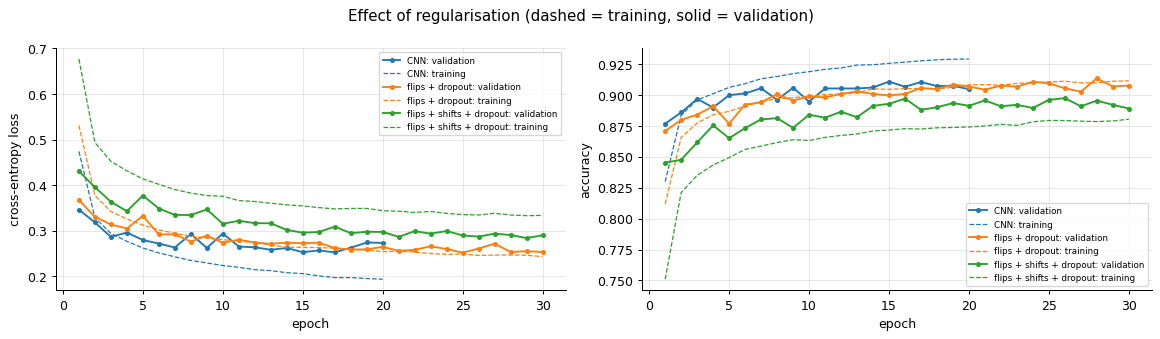

MLP 784-128-10                   0px: 0.883  1px: 0.804  2px: 0.532  3px: 0.334  4px: 0.257  5px: 0.266
CNN                              0px: 0.904  1px: 0.868  2px: 0.755  3px: 0.552  4px: 0.315  5px: 0.227
CNN + flips + dropout            0px: 0.901  1px: 0.877  2px: 0.799  3px: 0.578  4px: 0.327  5px: 0.235
CNN + flips + shifts + dropout   0px: 0.889  1px: 0.890  2px: 0.879  3px: 0.834  4px: 0.705  5px: 0.478


In [19]:
plot_histories({"CNN": hist_cnn, "flips + dropout": hist_flip, "flips + shifts + dropout": hist_reg},
               "Effect of regularisation (dashed = training, solid = validation)")
shift_results["CNN + flips + dropout"] = shift_curve(cnn_flip)
shift_results["CNN + flips + shifts + dropout"] = shift_curve(cnn_reg)
for name, accs in shift_results.items():
    print(f"{name:<32}", "  ".join(f"{s}px: {a:.3f}" for s, a in zip(shifts, accs)))

**What changed.**
- **Flips + dropout** closes the gap: the training accuracy falls to the level of the validation accuracy, so the model no longer memorises, and it keeps improving for many more epochs. The validation accuracy itself stays about the same. Differences of a few tenths of a percent change from run to run (GPU computations are not bit-for-bit reproducible), so do not over-read them.
- **Adding random shifts** makes the model far more **robust to shifted images**. We showed it shifted images during training, so it learned that position does not matter. Augmentation is the most direct way to teach a network an invariance.
- But on the normal, centred validation images, the shift-augmented model is clearly **worse** than the other two. With only 8 and 16 filters, the network has to spend part of its small capacity on handling shifts. Its training accuracy is now close to or below its validation accuracy: it is no longer overfitting, it is **underfitting**.

Regularisation is not free. When a model has no gap left, it is limited by its **capacity**, and the next step is a bigger model.

## 14. A stronger CNN: more filters, batch normalisation

Our CNN has only 8 and 16 filters. A typical small CNN for this dataset uses more filters, two convolutions per block, and **batch normalisation**:

- **More filters** (32, then 64): more patterns can be detected at each level.
- **Two $3 \times 3$ convolutions before each pooling**: the receptive field of two stacked $3 \times 3$ convolutions is $5 \times 5$, with fewer parameters and one more non-linearity than a single $5 \times 5$ filter.
- **Batch normalisation** (`nn.BatchNorm2d`): for each channel, standardise the activations over the batch to mean 0 and variance 1, then apply a learned scale and shift. It keeps the scale of the activations stable from layer to layer, which allows larger learning rates and faster training. Like dropout it behaves differently in `train` mode (batch statistics) and `eval` mode (running averages collected during training).
- **Global average pooling** at the end: each of the 64 feature maps is averaged to one number, so the classifier no longer depends on positions at all and has only $64 \cdot 10 + 10$ weights.

It is trained with the same flip + shift augmentation. This model is bigger, so it takes longer to train on a CPU.

In [20]:
def conv_block(c_in, c_out):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
        nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
        nn.MaxPool2d(2),
    )

class StrongCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(conv_block(1, 32), conv_block(32, 64))   # (B, 64, 7, 7)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),       # global average pooling -> (B, 64)
                                  nn.Dropout(dropout), nn.Linear(64, 10))

    def forward(self, x):
        return self.head(self.features(x))

summary(StrongCNN())
torch.manual_seed(0)
strong = StrongCNN()
hist_strong = fit(strong, train_loader_aug, val_loader, epochs=30)

layer          type               output shape          params
features.0.0   Conv2d             (1, 32, 28, 28)          320
features.0.1   BatchNorm2d        (1, 32, 28, 28)           64
features.0.2   ReLU               (1, 32, 28, 28)            0
features.0.3   Conv2d             (1, 32, 28, 28)        9,248
features.0.4   BatchNorm2d        (1, 32, 28, 28)           64
features.0.5   ReLU               (1, 32, 28, 28)            0
features.0.6   MaxPool2d          (1, 32, 14, 14)            0
features.1.0   Conv2d             (1, 64, 14, 14)       18,496
features.1.1   BatchNorm2d        (1, 64, 14, 14)          128
features.1.2   ReLU               (1, 64, 14, 14)            0
features.1.3   Conv2d             (1, 64, 14, 14)       36,928
features.1.4   BatchNorm2d        (1, 64, 14, 14)          128
features.1.5   ReLU               (1, 64, 14, 14)            0
features.1.6   MaxPool2d          (1, 64, 7, 7)              0
head.0         AdaptiveAvgPool2d  (1, 64, 1, 1)        

epoch  2  train loss 0.4840 acc 0.8253   val loss 0.3897 acc 0.8570   (1.8s)


epoch  4  train loss 0.3886 acc 0.8634   val loss 0.3110 acc 0.8886   (1.8s)


epoch  6  train loss 0.3420 acc 0.8810   val loss 0.2903 acc 0.8894   (2.0s)


epoch  8  train loss 0.3175 acc 0.8870   val loss 0.2658 acc 0.9024   (1.8s)


...

epoch 22  train loss 0.2483 acc 0.9115   val loss 0.2261 acc 0.9138   (1.9s)


epoch 24  train loss 0.2448 acc 0.9131   val loss 0.2145 acc 0.9140   (1.9s)


epoch 26  train loss 0.2388 acc 0.9145   val loss 0.2046 acc 0.9212   (1.8s)


epoch 28  train loss 0.2360 acc 0.9147   val loss 0.2011 acc 0.9256   (2.1s)


epoch 30  train loss 0.2298 acc 0.9183   val loss 0.2049 acc 0.9202   (1.9s)
-> restored epoch 28: val loss 0.2011, val acc 0.9256


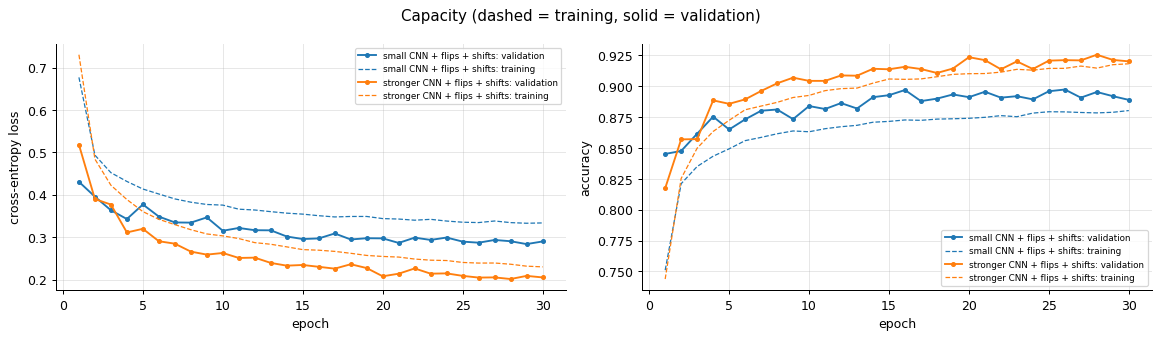

In [21]:
plot_histories({"small CNN + flips + shifts": hist_reg, "stronger CNN + flips + shifts": hist_strong}, "Capacity (dashed = training, solid = validation)")
shift_results["stronger CNN + flips + shifts"] = shift_curve(strong)

## 15. Final comparison on the test set

All choices were made on the validation set. We now report each model once on the test set, including the accuracy on test images shifted by 3 pixels.

model                               params  test acc  test loss  acc, 3px shift
MLP 784-128-10                     101,770    0.8833     0.3417           0.334
CNN                                  9,098    0.9040     0.2896           0.552
CNN + flips + dropout                9,098    0.9011     0.2808           0.578
CNN + flips + shifts + dropout       9,098    0.8893     0.3112           0.834
stronger CNN + flips + shifts       66,026    0.9206     0.2309           0.912


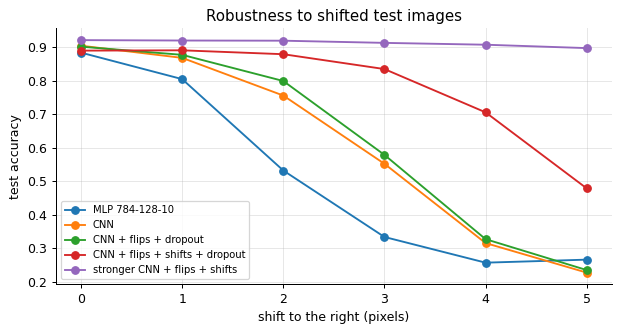

In [22]:
models = {"MLP 784-128-10": mlp, "CNN": cnn, "CNN + flips + dropout": cnn_flip,
          "CNN + flips + shifts + dropout": cnn_reg, "stronger CNN + flips + shifts": strong}
print(f"{'model':<32}{'params':>10}{'test acc':>10}{'test loss':>11}{'acc, 3px shift':>16}")
for name, m in models.items():
    tl, ta = evaluate(m, test_loader)
    print(f"{name:<32}{sum(p.numel() for p in m.parameters()):>10,}{ta:>10.4f}{tl:>11.4f}{shift_results[name][3]:>16.3f}")

fig, ax = plt.subplots(figsize=(7, 3.8))
for name, accs in shift_results.items():
    ax.plot(shifts, accs, "o-", label=name)
ax.set_xlabel("shift to the right (pixels)"); ax.set_ylabel("test accuracy"); ax.legend(fontsize=8)
ax.set_title("Robustness to shifted test images")
plt.tight_layout(); plt.show()

**Lessons from the table.**
- **Architecture matters more than size.** The small CNN beats the MLP with about a tenth of its parameters, because its assumptions (locality, weight sharing) match images.
- **Regularisation changes what the model learns, not only its accuracy.** Flips and dropout closed the gap between training and validation without changing the accuracy much. Shifts made the CNNs robust to shifts, something no amount of centred training data would teach, at a small cost in accuracy for the tiny model.
- **Once the gap is closed, add capacity.** The stronger CNN, with batch normalisation and global average pooling, is the best model on both centred and shifted images.

Beyond this point the usual next steps are longer training with a learning-rate schedule, deeper residual networks (ResNet) and, for real photos, **transfer learning**: starting from a network pretrained on millions of images. The face labs use exactly that.

## 16. Summary

- A convolution slides a small filter over the image: $O[i, j] = \sum_{u,v} I[i + u, j + v]\,K[u, v] + b$. **Locality** and **weight sharing** make it far cheaper than a dense layer: $(F^2 C_{\text{in}} + 1)\,C_{\text{out}}$ parameters, whatever the image size.
- Output size: $H_{\text{out}} = \lfloor (H + 2P - F)/S \rfloor + 1$. "Same" padding for $3 \times 3$ filters is $P = 1$.
- Convolution is **translation equivariant**. Pooling downsamples and adds a little invariance.
- The **receptive field** grows with depth: $R_l = R_{l-1} + (F_l - 1)J_{l-1}$. Our small CNN's final units see $10 \times 10$ pixels.
- A CNN = convolutional **feature extractor** + a classifier on the features. First-layer filters learn edge detectors; deeper layers combine them.
- **Data augmentation** creates label-preserving variations of the training images and teaches invariances. **Dropout** randomly removes units during training and is switched off in `eval` mode. Both reduce overfitting.
- **Batch normalisation** stabilises training of deeper networks. **Global average pooling** removes the dependence on position before the classifier.

## Exercises

Try each one before opening the answer.

1. **Receptive field.** Compute the receptive field of the units of the stronger CNN after its last pooling layer. What is the receptive field of two stacked $3 \times 3$ convolutions, and how many parameters do they need compared to one $5 \times 5$ convolution (with $C$ channels in and out)?
2. **Invariance vs equivariance.** Why is invariance to translation desirable for classification but not for localisation tasks, such as predicting the position of the eyes in a face?
3. **Parameter count.** Count the parameters of `StrongCNN` by hand. A `BatchNorm2d(C)` layer has $2C$ learnable parameters. Check your answer against `summary`.
4. **Dropout at inference.** Why must dropout be switched off at test time? What happens if you forget `model.eval()`?
5. **Augmentation choices.** For each dataset, would you use horizontal flips, vertical flips, small rotations? (a) handwritten digits, (b) satellite images, (c) photos of damaged cars.
6. **Validation curves.** After adding augmentation, the training accuracy is *lower* than without it. Is that a problem?

<details>
<summary><b>Answers</b></summary>

**1.** Use $R_l = R_{l-1} + (F_l - 1)J_{l-1}$. Block 1: first conv: $R = 1 + 2 = 3$, second conv: $R = 5$, pool: $R = 6$, $J = 2$. Block 2: conv: $R = 6 + 2 \cdot 2 = 10$, conv: $R = 14$, pool: $R = 14 + 1 \cdot 2 = 16$, $J = 4$. So each unit of the final $7 \times 7$ maps sees $16 \times 16$ pixels, and global average pooling then combines all positions. Two stacked $3 \times 3$ convolutions have a $5 \times 5$ receptive field ($3 + 2 = 5$). They need $2 \cdot 9C^2 = 18C^2$ weights against $25C^2$ for one $5 \times 5$ layer, and they add an extra ReLU between them. That is why modern CNNs (VGG, ResNet) use $3 \times 3$ filters almost everywhere.

**2.** In classification the answer should not change when the object moves: "shirt" is "shirt" anywhere, so we want the output to be invariant. In localisation the answer **is** the position: if the eyes move 5 pixels right, the predicted coordinates must move 5 pixels right. That requires equivariance, and too much pooling or global averaging throws away exactly the information needed. Detection and localisation networks therefore keep spatial feature maps until the end.

**3.** Block 1: conv $(9 \cdot 1 + 1) \cdot 32 = 320$, BN $64$, conv $(9 \cdot 32 + 1) \cdot 32 = 9{,}248$, BN $64$. Block 2: conv $(9 \cdot 32 + 1) \cdot 64 = 18{,}496$, BN $128$, conv $(9 \cdot 64 + 1) \cdot 64 = 36{,}928$, BN $128$. Head: $64 \cdot 10 + 10 = 650$. Total: $66{,}026$. Almost all parameters are in the convolutions, and the classifier is tiny thanks to global average pooling.

**4.** In training mode, each forward pass drops a different random set of units, so the prediction for the same image changes from call to call. It is noisy and usually a little worse. In `eval` mode all units are used, and the $1/(1-p)$ scaling during training guarantees that activations have the same expected size, so the prediction is deterministic. Forgetting `model.eval()` also leaves batch normalisation using the statistics of the current test batch instead of the training statistics, which can badly change the results, especially with small batches.

**5.** (a) Digits: no flips (a mirrored 2 or 7 is not a valid digit, and 6/9 swap under rotation by 180°), but small rotations and shifts are fine. (b) Satellite images: horizontal and vertical flips and rotations by any angle are all fine, since there is no "up" from above. (c) Damaged cars: horizontal flips are fine (a dent on the left door looks like one on the right), vertical flips are not (cars are never upside down in the photos), small rotations and brightness changes are fine. Always check that the transformation cannot change the label, for example if the label says "left door".

**6.** No. The training accuracy is measured on the augmented, harder images and with dropout active, so it is naturally lower. What matters is the validation accuracy on normal images, and the gap between the curves. A smaller gap with an equal or better validation score is exactly what regularisation should do.

</details>